#1 INTRODUCTION 

We are going to explore Linear Classifiers using dataset of statistics on fish.

In our case, we will look at a set of data where the length and width of different species of fish are so different that it is easy to "draw a line" between the two. Above a line will be on species of fish.  Below the line will be another. 


##PART 0 Installing libraries

In [1]:
!pip install pandas numpy matplotlib datasets

##0.1 Getting dataset

In [2]:
#Getting our dataset from a dataset repository on Huggingface
#Scikit-learn's Fish release under Creative Commons Attribution 4.0 
from datasets import load_dataset

df_load = load_dataset("scikit-learn/Fish")
df = df_load["train"].to_pandas()
print(df)

#You can also view or download this data manually by going to: 
#  https://huggingface.co/datasets/scikit-learn/Fish/tree/main
#  Click on Download button for Fish.csv

    Species  Weight  Length1  Length2  Length3   Height   Width
0     Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1     Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2     Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3     Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4     Bream   430.0     26.5     29.0     34.0  12.4440  5.1340
..      ...     ...      ...      ...      ...      ...     ...
154   Smelt    12.2     11.5     12.2     13.4   2.0904  1.3936
155   Smelt    13.4     11.7     12.4     13.5   2.4300  1.2690
156   Smelt    12.2     12.1     13.0     13.8   2.2770  1.2558
157   Smelt    19.7     13.2     14.3     15.2   2.8728  2.0672
158   Smelt    19.9     13.8     15.0     16.2   2.9322  1.8792

[159 rows x 7 columns]


#1 LINEAR REGRESSION

To make our study simpler, let's look at the first two types of fish. BREAM and ROACH. The following code will plot out both species.  
[] Intuition #1: These two fish are different sizes. We know that the Volume = Height x Length2 x Width is going to be related to the Weight. This is what the first set of code will plot.

[] Intuition #2: Though the linear regression for both fish are going to be similar; there are going to be differences in the "best fit" line. This is what the second set of code will show. 

Linear regression is not a way to classify these two fish. But it helps us to see the differences statistically. That BREAMS are clearly bigger than ROACH. And that a simple one-linear regression predictor doesn't work for both species. 



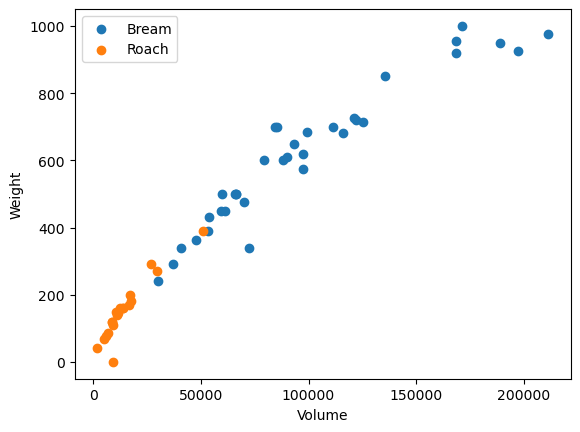

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Part 0.  Load data
# ============================================================
#df = pd.read_csv('Fish.csv') 
df['Volume'] = df['Height'] * (df['Length2']**2) * df['Width']

# Filter for Bream and Roach
df2 = df[df['Species'].isin(['Bream','Roach'])].copy()

# Separate species
bream = df2[df2['Species']=='Bream']
roach = df2[df2['Species']=='Roach']

# Extract x and y
x_b = bream['Volume'].values
y_b = bream['Weight'].values

x_r = roach['Volume'].values
y_r = roach['Weight'].values
plt.scatter(x_b, y_b, label='Bream')
plt.scatter(x_r, y_r, label='Roach')

plt.xlabel("Volume")
plt.ylabel("Weight")

plt.legend()
plt.show()

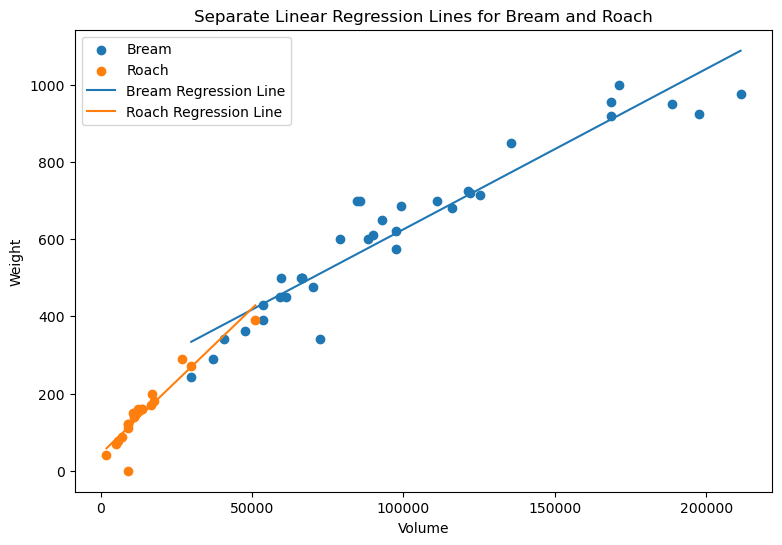

In [4]:
# ============================================================
# Part 1. Linear regression function
# ============================================================
# Linear regression function
def linear_regression(x, y):
    a = np.cov(x, y, bias=True)[0,1] / np.var(x)
    b = y.mean() - a * x.mean()
    return a, b

# Fit regressions
a_b, b_b = linear_regression(x_b, y_b)
a_r, b_r = linear_regression(x_r, y_r)

# Lines for plotting
x_line_b = np.linspace(x_b.min(), x_b.max(), 200)
y_line_b = a_b * x_line_b + b_b

x_line_r = np.linspace(x_r.min(), x_r.max(), 200)
y_line_r = a_r * x_line_r + b_r

# Plot
plt.figure(figsize=(9,6))

plt.scatter(x_b, y_b, label='Bream')
plt.scatter(x_r, y_r, label='Roach')

plt.plot(x_line_b, y_line_b, label='Bream Regression Line')
plt.plot(x_line_r, y_line_r, label='Roach Regression Line')

plt.xlabel("Volume")
plt.ylabel("Weight")
plt.title("Separate Linear Regression Lines for Bream and Roach")
plt.legend()
plt.show()

#2 LINEAR CLASSIFIER - GRADIENT DESCENT

A Classifier isn't trying to predict the y based on x.  The equation being: y = ax + b  -- where y = Weight of the fish as a function of x = Volume of fish.  

Instead, we want to start to classify if I have a value x and value y, what kind of fish is it?  The equation looks more like  w0x + w1y - bias = a prediction value. If it is Bream or if it is a Roach.

Below is a very involved set of code that I think illustrates visually what happens during the iterations. 
Step 1: We set X to be the data set of x, y or volume, weight.  y is now the classification. +1 for Breams, -1 for Roach.
Step 2: Volume is quite large. So creating a value Xs for which we can scale x down.
Step 3: We do base our initial "line" on the averages of the Linear Regressions for Bream and Roach.  This gives a starting point for w0 and bias.
w0_orig = an array of 1's and the a_ave (average of the slope).  In other words, 1 for w1 and a_ave for w0. 
b0_orig = is that equation of midpoint. 

Step 4: A bunch of utility functions that keep things within visible ranges.  w0, w1 and bias can create very large numbers if not drawn with in the axis we want to see. 

An explanation for sigmoid_stable. This is a function that will drive to 1 for one class and 0 for the other. For more depth, read: https://www.geeksforgeeks.org/machine-learning/derivative-of-the-sigmoid-function/

Step 5 and Step 6:  The initial plot and the gradient descent in action. 
There is a feed forward action, calculation of loss (aka -- difference between the right class and what was predicted), and an adjustment to w and b based on a gradient of the loss. 

Hit the "SPACE" button to see the changes for each step in the 25 epochs. 


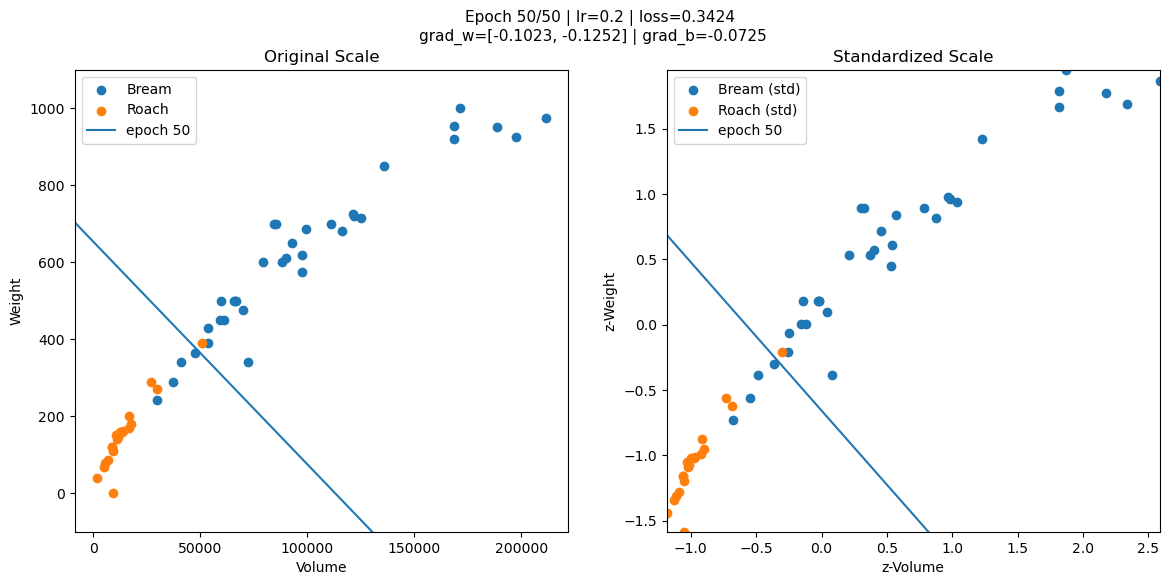

In [5]:
# ============================================================
# Part 2. Gradient Descent as a Linear Classifier
# (Notebook-safe: replot every N epochs)
# ============================================================
from IPython.display import clear_output
import time
# ------------------------------------------------------------
# STEP 1: BUILD THE DATASET (X) and LABELS (y)
# ------------------------------------------------------------
X = np.vstack([
    np.concatenate([x_b, x_r]),   # Volume
    np.concatenate([y_b, y_r])    # Weight
]).T

# Labels: +1 = Bream, -1 = Roach
y = np.concatenate([
    np.ones_like(x_b),
    -np.ones_like(x_r)
])

# ------------------------------------------------------------
# STEP 2: STANDARDIZE FEATURES
# ------------------------------------------------------------
mu = X.mean(axis=0)
sigma = X.std(axis=0)
Xs = (X - mu) / sigma

# ------------------------------------------------------------
# STEP 3: INITIAL LINE (midpoint, avg slope)
# ------------------------------------------------------------
a_ave = (a_b + a_r) / 2
w0_orig = np.array([1.0, a_ave])

mean_b = np.array([x_b.mean(), y_b.mean()])
mean_r = np.array([x_r.mean(), y_r.mean()])
midpoint = 0.5 * (mean_b + mean_r)

b0_orig = -np.dot(w0_orig, midpoint)

# Convert to standardized coordinates
w = w0_orig * sigma
b = np.dot(w0_orig, mu) + b0_orig

def normalize_wb(w, b, eps=1e-12):
    s = np.linalg.norm(w)
    if s < eps:
        return w, b
    return w / s, b / s

w, b = normalize_wb(w, b)

# ------------------------------------------------------------
# STEP 4: Helper functions
# ------------------------------------------------------------
def sigmoid_stable(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss(y, scores):
    margins = y * scores
    return np.mean(np.logaddexp(0.0, -margins))

def plot_boundary_segment(ax, w1, w2, b, x_min, x_max, y_min, y_max,
                          label=None, linestyle='-'):
    pts = []

    if abs(w2) > 1e-12:
        y1 = -(w1 * x_min + b) / w2
        y2 = -(w1 * x_max + b) / w2
        if y_min <= y1 <= y_max: pts.append((x_min, y1))
        if y_min <= y2 <= y_max: pts.append((x_max, y2))

    if abs(w1) > 1e-12:
        x1 = -(w2 * y_min + b) / w1
        x2 = -(w2 * y_max + b) / w1
        if x_min <= x1 <= x_max: pts.append((x1, y_min))
        if x_min <= x2 <= x_max: pts.append((x2, y_max))

    if len(pts) >= 2:
        (x1, y1), (x2, y2) = pts[:2]
        ax.plot([x1, x2], [y1, y2], linestyle=linestyle, label=label)

# ------------------------------------------------------------
# STEP 5: Plot limits
# ------------------------------------------------------------
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

x_pad = 0.05 * (x_max - x_min)
y_pad = 0.10 * (y_max - y_min)

x_min -= x_pad; x_max += x_pad
y_min -= y_pad; y_max += y_pad

z1_min, z1_max = Xs[:, 0].min(), Xs[:, 0].max()
z2_min, z2_max = Xs[:, 1].min(), Xs[:, 1].max()

Xb_s = (np.vstack([x_b, y_b]).T - mu) / sigma
Xr_s = (np.vstack([x_r, y_r]).T - mu) / sigma

# ------------------------------------------------------------
# STEP 6: Gradient Descent + periodic plotting
# ------------------------------------------------------------
lr = 0.2
epochs = 50
plot_every = 5

#plt.close("all")
#fig, (ax_orig, ax_std) = plt.subplots(1, 2, figsize=(14, 6))

for epoch in range(1, epochs + 1):

    # ----- forward -----
    scores = Xs @ w + b
    loss = logistic_loss(y, scores)

    # ----- gradients -----
    margins = y * scores
    p = sigmoid_stable(-margins)

    grad_w = np.mean((-y[:, None] * Xs) * p[:, None], axis=0)
    grad_b = np.mean((-y) * p)

    # ----- update -----
    w -= lr * grad_w
    b -= lr * grad_b
    w, b = normalize_wb(w, b)

    # ----- plot every N epochs -----
    if epoch % plot_every == 0 or epoch == 1 or epoch == epochs:
        clear_output(wait=True)

        fig, (ax_orig, ax_std) = plt.subplots(1, 2, figsize=(14, 6))
        ax_orig.cla()
        ax_std.cla()

        # Original scale
        ax_orig.scatter(x_b, y_b, label="Bream")
        ax_orig.scatter(x_r, y_r, label="Roach")

        w_orig = w / sigma
        b_orig = b - np.dot(w_orig, mu)

        plot_boundary_segment(
            ax_orig,
            w_orig[0], w_orig[1], b_orig,
            x_min, x_max, y_min, y_max,
            label=f"epoch {epoch}"
        )

        ax_orig.set_xlim(x_min, x_max)
        ax_orig.set_ylim(y_min, y_max)
        ax_orig.set_xlabel("Volume")
        ax_orig.set_ylabel("Weight")
        ax_orig.set_title("Original Scale")
        ax_orig.legend()

        # Standardized scale
        ax_std.scatter(Xb_s[:, 0], Xb_s[:, 1], label="Bream (std)")
        ax_std.scatter(Xr_s[:, 0], Xr_s[:, 1], label="Roach (std)")

        plot_boundary_segment(
            ax_std,
            w[0], w[1], b,
            z1_min, z1_max, z2_min, z2_max,
            label=f"epoch {epoch}"
        )

        ax_std.set_xlim(z1_min, z1_max)
        ax_std.set_ylim(z2_min, z2_max)
        ax_std.set_xlabel("z-Volume")
        ax_std.set_ylabel("z-Weight")
        ax_std.set_title("Standardized Scale")
        ax_std.legend()

        fig.suptitle(
            f"Epoch {epoch}/{epochs} | lr={lr} | loss={loss:.4f}\n"
            f"grad_w=[{grad_w[0]:.4f}, {grad_w[1]:.4f}] | grad_b={grad_b:.4f}   ",
            fontsize=11
        )
        
        plt.show()
        time.sleep(0.4)
# ------------------------------------------------------------
# STEP 7 Save the final weights and bias
# ------------------------------------------------------------
w_final = w.copy()
b_final = b

#3 MAKING THE PREDICTION:  
We will use the w and b that we trained -- w0x + w1y - bias to make predictions.
Pay special attention to where the user input in scaled:
x_user_std = (x_user - mu) / sigma

The weights are assumed to be for input values that are in that -1 to 1 range.

Enter values within these ranges:
  Length : [14.1, 41.0]
  Width  : [2.3,  6.7]
  Height : [4.1, 19.0]
  Weight : [0.0, 1000.0]
Good test values are Bream 500 30 14 5. Roach is 110 20 6 3 


Weight:  500
Length:  30
Height:  14
Width :  5



--- Prediction (Final Epoch Model) ---
Volume computed : 63000.00
Raw score       : 0.4922
Prediction      : Bream
Confidence*     : 0.62

*Confidence is derived from distance to the decision boundary.


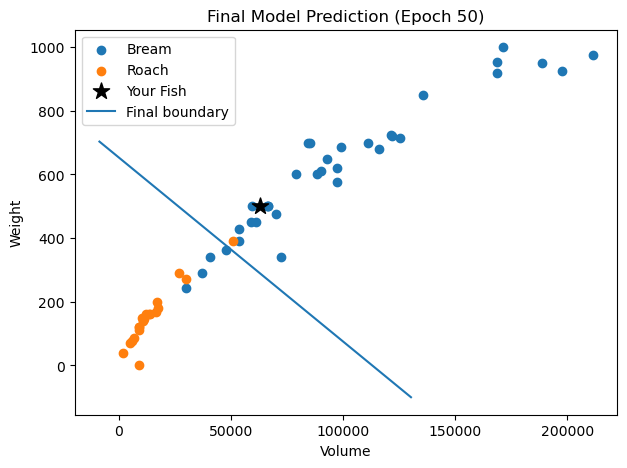

In [6]:
# ============================================================
# Part 3. User Input → Prediction (Final Epoch Model)
# ============================================================

# ------------------------------------------------------------
# STEP 1: Valid input ranges (from training data)
# ------------------------------------------------------------
length_min, length_max = df2['Length2'].min(), df2['Length2'].max()
width_min,  width_max  = df2['Width'].min(),  df2['Width'].max()
height_min, height_max = df2['Height'].min(), df2['Height'].max()
weight_min, weight_max = df2['Weight'].min(), df2['Weight'].max()

print("Enter values within these ranges:")
print(f"  Length : [{length_min:.1f}, {length_max:.1f}]")
print(f"  Width  : [{width_min:.1f},  {width_max:.1f}]")
print(f"  Height : [{height_min:.1f}, {height_max:.1f}]")
print(f"  Weight : [{weight_min:.1f}, {weight_max:.1f}]")
print("Good test values are Bream 500 30 14 5. Roach is 110 20 6 3 ")
# ------------------------------------------------------------
# STEP 2: User input
# ------------------------------------------------------------
weight = float(input("Weight: "))
length = float(input("Length: "))
height = float(input("Height: "))
width  = float(input("Width : "))


# Optional: basic range check
assert length_min <= length <= length_max, "Length out of range"
assert width_min  <= width  <= width_max,  "Width out of range"
assert height_min <= height <= height_max, "Height out of range"
assert weight_min <= weight <= weight_max, "Weight out of range"

# ------------------------------------------------------------
# STEP 3: Feature construction (must match training)
# ------------------------------------------------------------
volume = height * (length ** 2) * width
x_user = np.array([volume, weight])

# Standardize using TRAINING statistics
x_user_std = (x_user - mu) / sigma

# ------------------------------------------------------------
# STEP 4: Prediction using FINAL model
# ------------------------------------------------------------
score = np.dot(w_final, x_user_std) + b_final

prediction = "Bream" if score >= 0 else "Roach"
confidence = 1.0 / (1.0 + np.exp(-abs(score)))  # optional, intuitive

# ------------------------------------------------------------
# STEP 5: Output
# ------------------------------------------------------------
print("\n--- Prediction (Final Epoch Model) ---")
print(f"Volume computed : {volume:.2f}")
print(f"Raw score       : {score:.4f}")
print(f"Prediction      : {prediction}")
print(f"Confidence*     : {confidence:.2f}")

print("\n*Confidence is derived from distance to the decision boundary.")

plt.figure(figsize=(7, 5))
plt.scatter(x_b, y_b, label="Bream")
plt.scatter(x_r, y_r, label="Roach")

plt.scatter(volume, weight,
            s=150,
            marker="*",
            color="black",
            label="Your Fish")

# Final decision boundary
w_orig = w_final / sigma
b_orig = b_final - np.dot(w_orig, mu)

plot_boundary_segment(
    plt.gca(),
    w_orig[0], w_orig[1], b_orig,
    x_min, x_max, y_min, y_max,
    label="Final boundary"
)

plt.xlabel("Volume")
plt.ylabel("Weight")
plt.title("Final Model Prediction (Epoch 50)")
plt.legend()
plt.show()